Let $x(t)$ be the population size governed by the DE

$$
\dot x = r_0x(1-(x/k)) - \frac{B x^2}{A+x^2}
$$

Suppose we only know the logistic term, and we want to approximate the other term with an universal approximator (such as an NN). So we have the UDE

$$
\dot x = r_0x(1-(x/k)) - \texttt{NN}_\theta(x, t)
$$

Our goal is to demonstrate our method of fitting the NN to the training data (which will be generated with a simulation of $x(t)$). In particular, we have the loss

$$
\mathcal L(\theta) := \sum_n (x_\theta(t_n)-\hat x_n)^2
$$

Whose gradient is calculated as

$$
\nabla_\theta \mathcal L = 2 \sum_n (x_\theta(t_n)-\hat x_n) \cdot \frac{\partial x_\theta}{\partial \theta}
$$

Moreover we will numerically simulate $x(t)$ with Newton's algorithm, which is given as

$$
x(t_{k+1}) = x(t_k) + h\mathcal F(\texttt{NN}_\theta, x, t)
$$

We will calculate the derivatives with *automatic differentiation*, provided by PyTorch.

In [2]:
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from torch import nn
import torch


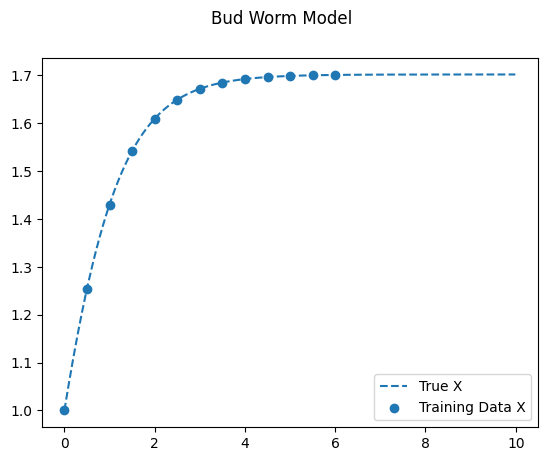

In [3]:
# Part 1: Synthetic Data Generation
r0 = 2
K = 3
A = 3
B = 3

def budworm(t, data, r0, K, A, B):
    x = data[0]
    return np.array([r0*x*(1-(x/K)) - (A* (x**2))/(B+(x**2))])

sol = solve_ivp(budworm, t_span = [0, 10], args= (r0, K, A, B), y0 = [1], rtol=1e-9, atol=1e-9, t_eval=np.arange(0, 10, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")

T_train = T[:601:50]
X_train = X[:601:50]

plt.scatter(T_train, X_train, label="Training Data X")

plt.legend()
plt.suptitle("Bud Worm Model")
plt.show()




In [16]:
# define universal budworm model

class universal_budworm(nn.Module):
    def __init__(self, x0, r0, K):
        super().__init__()
        self.r0 = r0
        self.K = K
        self.x0 = x0

        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.SiLU(),
            nn.Linear(32,32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )       

    def forward(self, x, t):
        # returns dx/dt
        return self.r0*x*(1-x/self.K) - self.net(x)

In [17]:
my_budworm = universal_budworm(
    x0=1,
    r0=2,
    K=3
)

In [18]:
def euler_solver(x0, model, t_eval):
    "Euler method for arbitrary mesh points, uses pytorch to maintain gradients"

    x_list = [x0.clone()]
    x_curr = x0.clone()
    
    for i in range(1, len(t_eval)):
        # Time step
        dt = float(t_eval[i] - t_eval[i-1])
        
        # Calculate dx/dt from the model
        dxdt = model(x_curr.view(1), torch.tensor(float(t_eval[i-1])))
        
        # Calculate next point
        x_next = x_curr + dt * dxdt.squeeze()
        x_list.append(x_next)
        
        x_curr = x_next
    
    return torch.stack(x_list)


In [19]:
x_euler = euler_solver(torch.tensor([1.]), my_budworm, t_euler := np.arange(0, 10, 0.001))

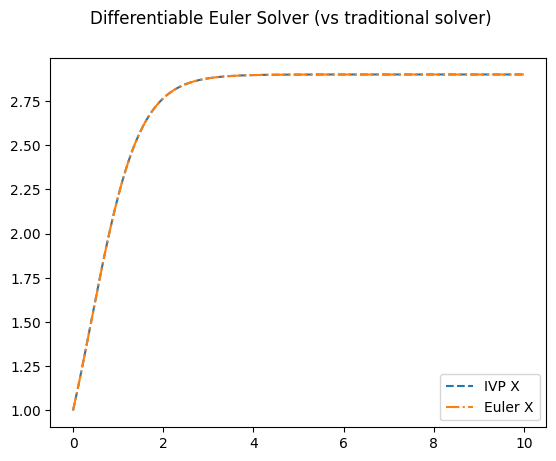

In [8]:
def ivp_universal_budworm(t, data, r0, K):
    x = data[0]
    return np.array([r0*x*(1-(x/K)) - my_budworm.net(torch.tensor(data, dtype=torch.float32)).detach().numpy()])

sol = solve_ivp(ivp_universal_budworm, t_span = [0, 10], args= (r0, K), y0 = [1], rtol=1e-9, atol=1e-9, dense_output=True)
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="IVP X")
plt.plot(t_euler,x_euler.detach().numpy(), "-.", label="Euler X")

plt.legend()

plt.suptitle("Differentiable Euler Solver (vs traditional solver)")

plt.show()

In [20]:
from tqdm import tqdm 

my_budworm = universal_budworm(
    x0=1,
    r0=2,
    K=3
)
lr = 0.01
optimizer = torch.optim.Adam(my_budworm.parameters(), lr=lr)

n_epochs = 3000

rtol = 1e-7

losses = []

x_train_torch = torch.tensor(X_train, dtype=torch.float32)
for EPOCH in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = euler_solver(torch.tensor(1.0), my_budworm, torch.tensor(T_train))
    
    # Compute loss at training points
    optimizer.zero_grad()

    loss = torch.mean(torch.pow(x_pred-x_train_torch, 2))
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        losses.append(loss.detach())
        #print(f"{EPOCH}\t{loss.item()}")

100%|██████████| 3000/3000 [00:11<00:00, 258.10it/s]


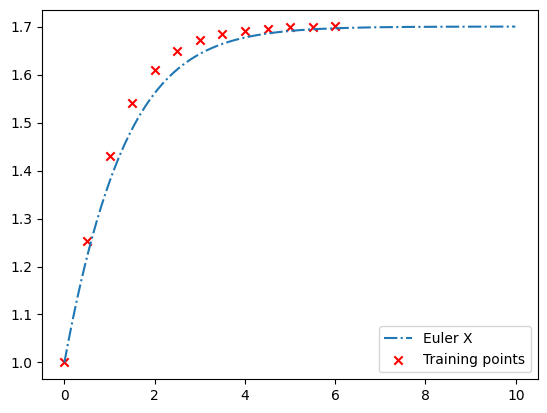

In [21]:
x_euler = euler_solver(torch.tensor([1.]), my_budworm, t_euler := torch.arange(0, 10, 0.01))                       

plt.plot(t_euler,x_euler.detach().numpy(), "-.", label="Euler X")
plt.scatter(T_train, X_train, marker="x", color='r', label="Training points")

plt.legend()

plt.show()

In [22]:
def agnesi(A, B, x):
    return (A * (x**2))/(B+(x**2))

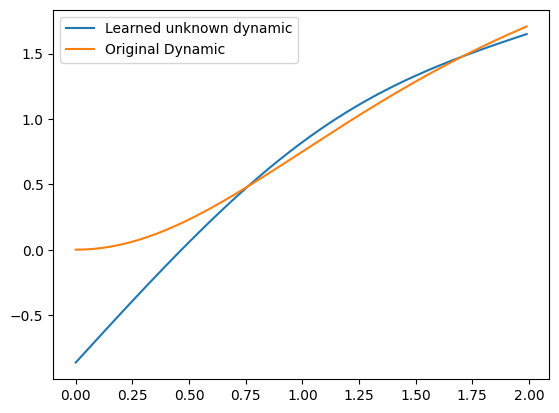

In [23]:
y = torch.zeros(torch.arange(0,2,0.01).shape)
y_target = torch.zeros(torch.arange(0,2,0.01).shape)

for i, x in enumerate(torch.arange(0, 2, 0.01)):
    y[i] = my_budworm.net(torch.tensor([x]))
    y_target[i] = agnesi(3, 3, x)

y_np = y.detach().numpy()
y_np_agnesi = y_target.detach().numpy()

plt.plot(np.arange(0,2,0.01), y_np, label="Learned unknown dynamic")
plt.plot(np.arange(0,2,0.01), y_np_agnesi, label="Original Dynamic")

plt.legend()

plt.show()

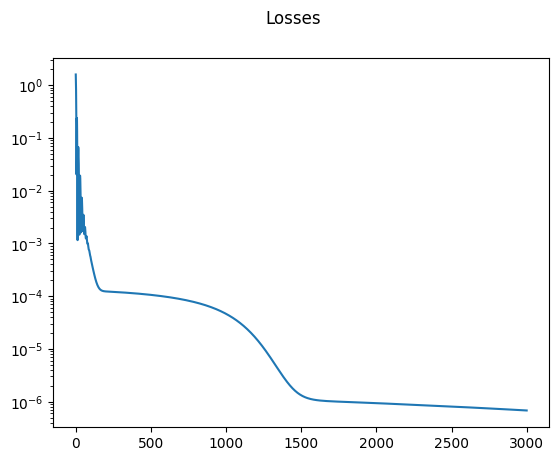

In [24]:
plt.semilogy(losses)
plt.suptitle("Losses")
plt.show()

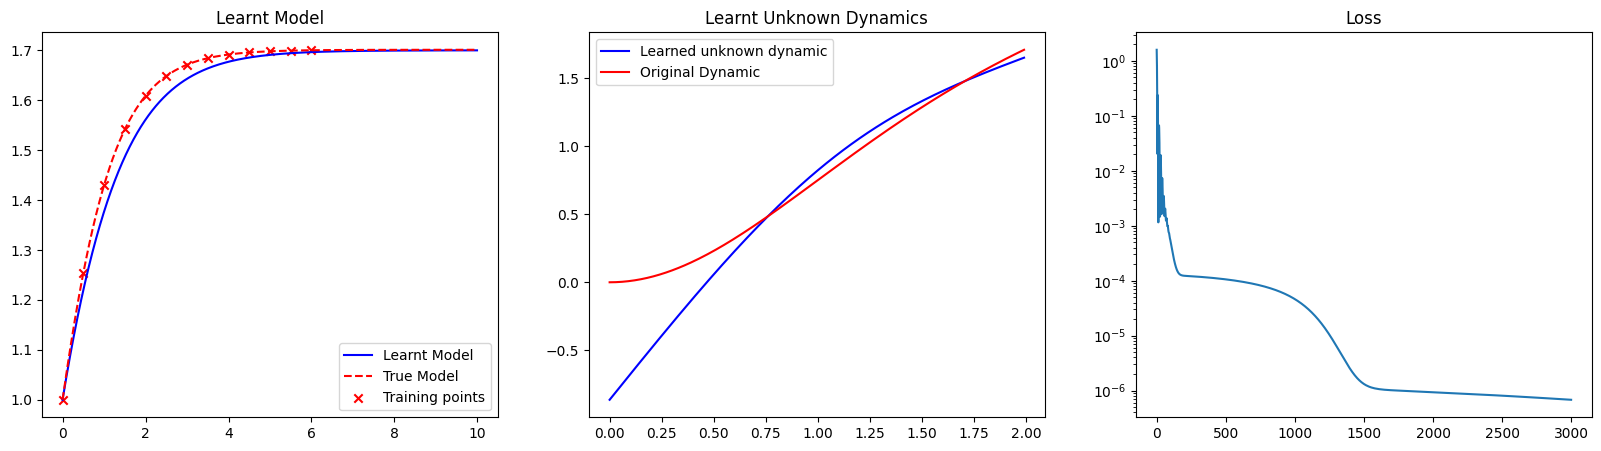

In [25]:
# summary of three plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax0 = axes[0]
ax1 = axes[1]
ax2 = axes[2]

x_euler = euler_solver(torch.tensor([1.]), my_budworm, t_euler := torch.arange(0, 10, 0.01))                       
ax0.plot(t_euler,x_euler.detach().numpy(), label="Learnt Model", color="blue")
x_true = solve_ivp(budworm, t_span = [0, 10], args= (r0, K, A, B), y0 = [1], rtol=1e-9, atol=1e-9, t_eval=t_euler).y
ax0.plot(t_euler, x_true.reshape(-1, 1), label="True Model", color="red", linestyle="--")
ax0.scatter(T_train, X_train, marker="x", color='r', label="Training points")
ax0.legend()

ax0.set_title("Learnt Model")

y = torch.zeros(torch.arange(0,2,0.01).shape)
y_target = torch.zeros(torch.arange(0,2,0.01).shape)

for i, x in enumerate(torch.arange(0, 2, 0.01)):
    y[i] = my_budworm.net(torch.tensor([x]))
    y_target[i] = agnesi(3, 3, x)

y_np = y.detach().numpy()
y_np_agnesi = y_target.detach().numpy()

ax1.plot(np.arange(0,2,0.01), y_np, label="Learned unknown dynamic", color="blue")
ax1.plot(np.arange(0,2,0.01), y_np_agnesi, label="Original Dynamic", color="red")

ax1.legend()
ax1.set_title("Learnt Unknown Dynamics")


ax2.semilogy(losses)
ax2.set_title("Loss")

plt.show()

In [26]:
losses[-1]

tensor(6.7945e-07)

This is the essence of UDEs; to improve the methology, one can consider using more accurate DE solvers (such as the Runge-Kutta methods), or the adjoint method as described in Rackauckas' paper.